<a href="https://colab.research.google.com/github/PY-1-001/Distributed_wildlife_CNN_Group46/blob/main/Assignment2_ML_Group46.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''install and check GPUs'''
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch Version: 2.9.0+cu128
CUDA Available: True
GPU Name: Tesla T4


In [2]:
'''import the data and set data path'''
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("biancaferreira/african-wildlife")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'african-wildlife' dataset.
Path to dataset files: /kaggle/input/african-wildlife


In [4]:
'''set data path'''
import os

data_path = "/kaggle/input/african-wildlife"

# Check subfolders
print("Folders inside dataset:")
print(os.listdir(data_path))

Folders inside dataset:
['buffalo', 'elephant', 'zebra', 'rhino']


In [5]:
'''Create Train/Validation split'''
import shutil
import random

train_dir = "wildlife_data/train"
val_dir = "wildlife_data/val"

classes = os.listdir(data_path)

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    images = os.listdir(os.path.join(data_path, cls))
    random.shuffle(images)

    split = int(0.8 * len(images))
    train_images = images[:split]
    val_images = images[split:]

    for img in train_images:
        shutil.copy(os.path.join(data_path, cls, img),
                    os.path.join(train_dir, cls, img))

    for img in val_images:
        shutil.copy(os.path.join(data_path, cls, img),
                    os.path.join(val_dir, cls, img))

print("Train/Validation split completed!")

Train/Validation split completed!


In [6]:
'''Load Dataset'''
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['buffalo', 'elephant', 'rhino', 'zebra']


In [7]:
'''Load ResNet Model'''
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)

print("Model loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Model loaded successfully!


In [8]:
'''Loss and Optimizer'''
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
'''Train Model (with Timing)'''
import time

epochs = 5
start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

end_time = time.time()

print("Total Training Time:", round(end_time - start_time, 2), "seconds")

Epoch 1/5, Loss: 27.2711
Epoch 2/5, Loss: 10.0509
Epoch 3/5, Loss: 5.8302
Epoch 4/5, Loss: 5.3119
Epoch 5/5, Loss: 6.3076
Total Training Time: 88.17 seconds


In [10]:
'''Evaluate Accuracy'''
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 75.85%


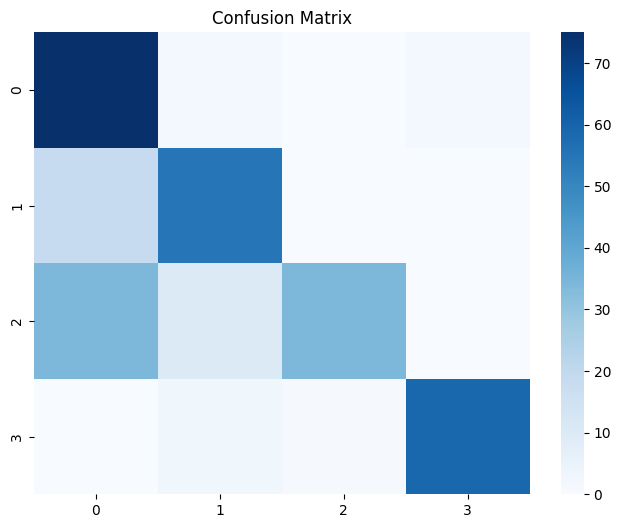

In [11]:
'''Confusion Matrix'''
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()